## <span style="color:#50C878; font-weight:bold;">Load in Data</span>

In [102]:
%pip install matplotlib
%pip install seaborn


Note: you may need to restart the kernel to use updated packages.


Could not find platform independent libraries <prefix>


Note: you may need to restart the kernel to use updated packages.


Could not find platform independent libraries <prefix>


In [103]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.feature_selection import RFE
import numpy as np
from sklearn.feature_selection import VarianceThreshold
import joblib
from collections import defaultdict
from scipy import stats
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


# Load the dataset
data = pd.read_csv('../../data/Car_Kh24.csv')

df = pd.DataFrame(data)

df.info()
# data.isnull().sum()
# df.nunique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17873 entries, 0 to 17872
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ad ID         17873 non-null  int64  
 1   Category      17873 non-null  object 
 2   Locations     17873 non-null  object 
 3   Car Makes     17870 non-null  object 
 4   Car Model     17750 non-null  object 
 5   Year          17871 non-null  float64
 6   Tax Type      17873 non-null  object 
 7   Condition     17873 non-null  object 
 8   Body Type     14215 non-null  object 
 9   Fuel          15712 non-null  object 
 10  Transmission  16387 non-null  object 
 11  Color         17685 non-null  object 
 12  Link          17873 non-null  object 
 13  Title         17873 non-null  object 
 14  Price         17873 non-null  object 
 15  Year Used     17871 non-null  float64
dtypes: float64(2), int64(1), object(13)
memory usage: 2.2+ MB


## <span style="color:#50C878; font-weight:bold;">Data Preprocessing</span>

### <span style="color:#50C878; font-weight:bold;">Remove NULL Row</span>


In [104]:
feature_has_missing_values = [
    feature for feature in df.columns if df[feature].isnull().any()
]
df = df.dropna(subset=feature_has_missing_values, how="any")
df.isnull().sum()

Ad ID           0
Category        0
Locations       0
Car Makes       0
Car Model       0
Year            0
Tax Type        0
Condition       0
Body Type       0
Fuel            0
Transmission    0
Color           0
Link            0
Title           0
Price           0
Year Used       0
dtype: int64

### <span style="color:#50C878; font-weight:bold;">Remove Duplicate Data</span>


In [105]:
# find duplicates
duplicates = df[df.duplicated()]

# count duplicates
print(f"Number of duplicate rows: {len(duplicates)}")

#drop duplicates
df = df.drop_duplicates()

Number of duplicate rows: 3


### <span style="color:#50C878; font-weight:bold;">Remove Unknown Data</span>


In [106]:
def check_column_value(df, value):
    """
    Checks if each column in a pandas DataFrame contains a specific value and prints the column names that contain the value.
    
    Parameters:
        df (pandas DataFrame): The DataFrame to check.
        value (any type): The value to look for in each column.
    """
    values = value if isinstance(value, list) else [value]
    matching_columns = df.apply(lambda col: col.isin(values).any())
    matching_columns = matching_columns[matching_columns]

    count = defaultdict(list)
    index = set()

    for val in values:
        for col in matching_columns.index:
            count[col].append(df[df[col] == val].shape[0])
            index.update(df[df[col] == val].index)

    print(f"\033[94mColumns that contain {values}:\n")
    print(pd.Series(count))

    return index

In [107]:
index = check_column_value(df, ['Other', 'Other - ផ្សេងៗ'])
df = df.drop(index, axis='rows')

Columns that contain ['Other', 'Other - ផ្សេងៗ']:



Car Model     [0, 53]
Body Type    [920, 0]
Color        [274, 0]
dtype: object


### <span style="color:#50C878; font-weight:bold;">Drop Unused Columns</span>

In [108]:
df.columns = df.columns.str.strip()

# columns_to_drop = ['Ad ID', 'Category', 'Locations', 'Fuel', 'Transmission', 'Color', 'Link', 'Title', 'Year Used']
columns_to_drop = ['Ad ID', 'Category', 'Locations', 'Link', 'Title']

df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

df.columns

Index(['Car Makes', 'Car Model', 'Year', 'Tax Type', 'Condition', 'Body Type',
       'Fuel', 'Transmission', 'Color', 'Price', 'Year Used'],
      dtype='object')

### <span style="color:#50C878; font-weight:bold;">Convert Price from String to Float</span>

In [109]:
df['Price'] = df['Price'].apply(lambda x: x.split('$')[1].replace(',', '')).astype(float)
df['Price'].dtype

dtype('float64')

### <span style="color:#50C878; font-weight:bold;">Feature Engineering</span>

In [110]:
# Add 'Car Age' feature
df['Car Age'] = 2025 - df['Year']


### <span style="color:#50C878; font-weight:bold;">Handle Skewed Data</span>

C:\Users\PCN\AppData\Local\Temp\ipykernel_22844\1392703603.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  t=sns.distplot(Boxcox,label="Skewness: %.2f"%(Boxcox.skew()) )


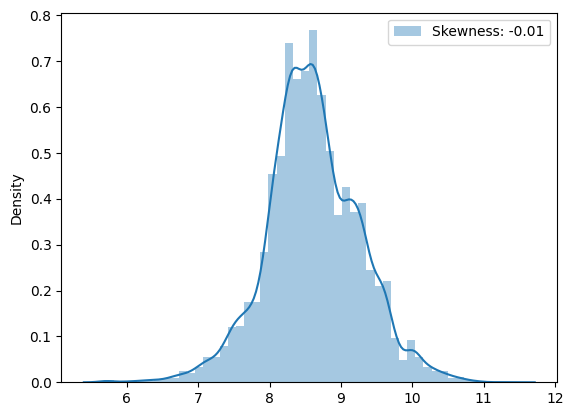

In [111]:
def boxcox(new_df, col):

    # Box-Cox transformation
    transformed_data, lambda_param = stats.boxcox(new_df[col])

    Boxcox = pd.Series(transformed_data)
    
    t=sns.distplot(Boxcox,label="Skewness: %.2f"%(Boxcox.skew()) )
    t.legend()
    return Boxcox, lambda_param

price_boxcox, price_lambda = boxcox(df, 'Price')

C:\Users\PCN\AppData\Local\Temp\ipykernel_22844\1392703603.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  t=sns.distplot(Boxcox,label="Skewness: %.2f"%(Boxcox.skew()) )


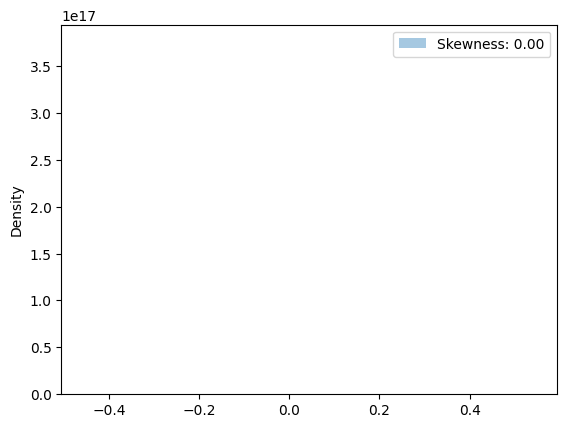

In [112]:
year_boxcox, year_lambda = boxcox(df, 'Year')

In [113]:
df_boxcox = df.copy()
df_boxcox['Price'] = list(price_boxcox)
df_boxcox.shape, df.shape

((11859, 12), (11859, 12))

### <span style="color:#50C878; font-weight:bold;">Detect Outlier</span>

In [114]:
# func to Inter-quartile Range Method
def out_iqr(df , column):
    global lower,upper
    q25, q75 = np.quantile(df[column], 0.25), np.quantile(df[column], 0.75)
    # calculate the IQR
    iqr = q75 - q25
    # calculate the outlier cutoff
    cut_off = iqr * 1.5
    # calculate the lower and upper bound value
    lower, upper = q25 - cut_off, q75 + cut_off
    print('The IQR is',iqr)
    print('The lower bound value is', lower)
    print('The upper bound value is', upper)
    # Calculate the number of records below and above lower and above bound value respectively
    df1 = df[df[column] > upper]
    df2 = df[df[column] < lower]
    return print('Total number of outliers are', df1.shape[0]+ df2.shape[0])

In [115]:
def visualize_outlier(df, col):
    out_iqr(df, col)
    plt.figure(figsize = (10,6))
    sns.distplot(df[col], kde=False)
    plt.axvspan(xmin = lower,xmax= df.Price.min(),alpha=0.2, color='red')
    plt.axvspan(xmin = upper,xmax= df.Price.max(),alpha=0.2, color='red')
    plt.show()

In [116]:
# visualize_outlier(df_boxcox, 'Price')

In [117]:
# visualize_outlier(df, 'Price')

### <span style="color:#50C878; font-weight:bold;">Remove Outlier</span>

In [118]:
def outlier_detection(df):
    Q1 = df.quantile(0.25)
    Q3 = df.quantile(0.75)
    IQR = Q3 - Q1
    upper_end = Q3 + 1.5 * IQR
    lower_end = Q1 - 1.5 * IQR
    outlier = df[(df > upper_end) | (df < lower_end)]
    return outlier

In [119]:
# # Define price threshold (optional, based on your data)
# price_lower_threshold = df['Price'].quantile(0.25)
# price_upper_threshold = df['Price'].quantile(0.75)

# # Filter out rows where price is out of the defined range
# df = df[(df['Price'] > price_lower_threshold) & (df['Price'] < price_upper_threshold)]

outlier_index = list(outlier_detection(df_boxcox['Price']).index)
df = df_boxcox.drop(outlier_index, axis= 'rows')
print(outlier_index)

[155, 266, 339, 350, 533, 536, 591, 702, 780, 937, 978, 1138, 1177, 1179, 1215, 1262, 1265, 1267, 1507, 1565, 1802, 1806, 1846, 1859, 2008, 2047, 2267, 2489, 2673, 2727, 2728, 2730, 2765, 2862, 2941, 2951, 2975, 2989, 2999, 3206, 3214, 3216, 3218, 3221, 3223, 3227, 3228, 3229, 3232, 3233, 3238, 3261, 3393, 3594, 3654, 3656, 3701, 3754, 3937, 4140, 4158, 4194, 4212, 4633, 4720, 4777, 4835, 4839, 4865, 4866, 4885, 4906, 4931, 4999, 5027, 5045, 5193, 5246, 5248, 5251, 5252, 5255, 5345, 5436, 5494, 5500, 5501, 5561, 5609, 5678, 5688, 5713, 5724, 6078, 6172, 6270, 6411, 6429, 6607, 6767, 6918, 7078, 7085, 7294, 7483, 7504, 7529, 7594, 7783, 7918, 7981, 8025, 8144, 8228, 8352, 8357, 8420, 8486, 8587, 8804, 8900, 8920, 9232, 9344, 9369, 9370, 9372, 9505, 9643, 9697, 9714, 9813, 9815, 10021, 10381, 10424, 10641, 10698, 10799, 11006, 11064, 11085, 11176, 11183, 11320, 11322, 11463, 11544, 11549, 11828, 12086, 12164, 12264, 12285, 12286, 12321, 12378, 12487, 12844, 12848, 12942, 13087, 13198, 13

### <span style="color:#50C878; font-weight:bold;">Encoding</span>

In [120]:
categorical_features = df.select_dtypes(include=['object']).columns.tolist()
categorical_features

['Car Makes',
 'Car Model',
 'Tax Type',
 'Condition',
 'Body Type',
 'Fuel',
 'Transmission',
 'Color']

In [121]:
# # Label Encoding
# le = LabelEncoder()

# # Columns to encode
# categorical_cols = ['Car Model']

# # Apply label encoding to categorical columns
# for col in categorical_cols:
#     df[col] = le.fit_transform(df[col])

# # One-Hot Encoding
# df = pd.get_dummies(df, columns=['Car Makes', 'Tax Type', 'Condition', 'Body Type'])

df = pd.get_dummies(df, columns=categorical_features)

# # df.head()

# Target Encoding
# target_encoder = ce.TargetEncoder(cols= categorical_features)

## <span style="color:#50C878; font-weight:bold;">Model</span>

### <span style="color:#50C878; font-weight:bold;">Train the Elastic Net Regression Model</span>

In [122]:
X = df.drop(columns=['Price'])
print(df.head())
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save the scaler for future use
# joblib.dump(scaler, 'scaler.pkl')
# print("Scaler saved as 'scaler.pkl'")

     Year      Price  Year Used  Car Age  Car Makes_Acura  \
0  2003.0   8.364745       20.0     22.0            False   
2  2022.0  10.138269        1.0      3.0            False   
3  2004.0   8.654175       19.0     21.0            False   
6  2013.0   8.091211       10.0     12.0            False   
7  2013.0   8.757067       10.0     12.0            False   

   Car Makes_Alfa Romeo  Car Makes_Aston Martin  Car Makes_Audi  \
0                 False                   False           False   
2                 False                   False           False   
3                 False                   False           False   
6                 False                   False           False   
7                 False                   False           False   

   Car Makes_BAIC  Car Makes_BESTUNE  ...  Color_Brown  Color_Gold  \
0           False              False  ...        False       False   
2           False              False  ...        False       False   
3           False   

In [123]:
print(X_train)

         Year  Year Used  Car Age  Car Makes_Acura  Car Makes_Alfa Romeo  \
1887   2001.0       22.0     24.0            False                 False   
5078   2013.0       10.0     12.0            False                 False   
9062   2021.0        2.0      4.0            False                 False   
8647   2014.0        9.0     11.0            False                 False   
5002   2016.0        7.0      9.0            False                 False   
...       ...        ...      ...              ...                   ...   
1618   2006.0       17.0     19.0            False                 False   
3697   2017.0        6.0      8.0            False                 False   
9903   2009.0       14.0     16.0            False                 False   
3781   2007.0       16.0     18.0            False                 False   
11011  2005.0       18.0     20.0            False                 False   

       Car Makes_Aston Martin  Car Makes_Audi  Car Makes_BAIC  \
1887                  

In [124]:
%pip install tensorflow


Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: tensorflow in d:\general\itc\i5-gic\semester-1\ai\project\car price prediction\.venv\lib\site-packages (2.18.0)



Could not find platform independent libraries <prefix>


Epoch 1/150


d:\General\ITC\I5-GIC\Semester-1\AI\Project\Car Price Prediction\.venv\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


291/291 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 3.7184 - mae: 1.0741 - val_loss: 0.2592 - val_mae: 0.4258
Epoch 2/150
291/291 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2431 - mae: 0.3971 - val_loss: 0.2317 - val_mae: 0.4074
Epoch 3/150
291/291 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1665 - mae: 0.3176 - val_loss: 0.2435 - val_mae: 0.4271
Epoch 4/150
291/291 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1991 - mae: 0.3542 - val_loss: 0.0845 - val_mae: 0.2053
Epoch 5/150
291/291 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1193 - mae: 0.2582 - val_loss: 0.0926 - val_mae: 0.2364
Epoch 6/150
291/291 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1230 - mae: 0.2581 - val_loss: 0.0960 - val_mae: 0.2444
Epoch 7/150
291/291 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1138 - mae: 0.2643 - val_loss: 0.0669 - val_mae: 0.1872
Epoch 8/150
291/291 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0754 - mae: 0.2033 - val_loss: 0.1119 - val_mae: 0.2764
Epoch 9/150
291/291 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss:

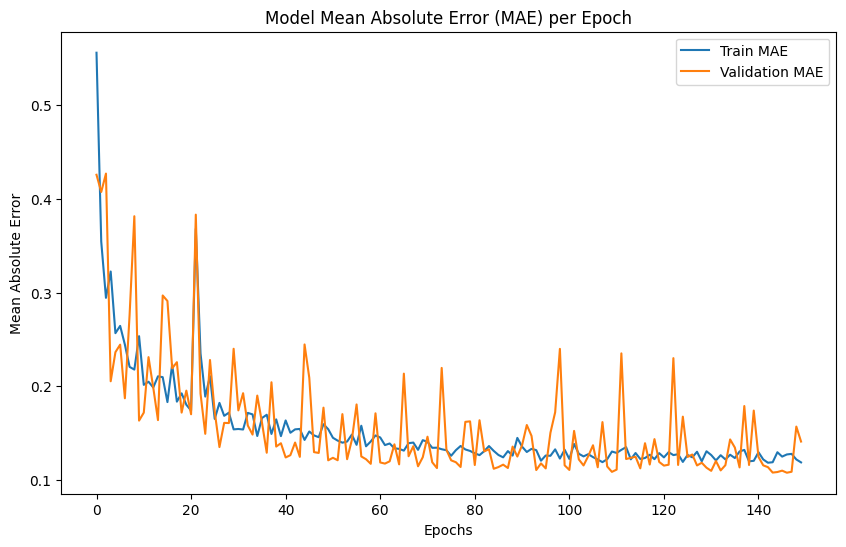

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# Initialize the model
model = Sequential()

# Add layers
model.add(Dense(128, input_dim=X_train.shape[1], activation='relu'))
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))

model.add(Dense(1))
optimizer = Adam(learning_rate=0.001)

# Compile the model
model.compile(optimizer=optimizer, loss='mean_squared_error', metrics=['mae'])

# Train the model and store the history
history = model.fit(X_train, y_train, epochs=150, batch_size=32, validation_data=(X_test, y_test))




In [ ]:
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")
print(f"Mean Absolute Error: {mae}")
print(f"R-squared: {r2}")
# Show the predictions alongside the actual values
results = pd.DataFrame({'Actual': y_test, 'Predicted': predictions.flatten()})

In [ ]:
# Extract training and validation MAE (Mean Absolute Error)
train_mae = history.history['mae']
val_mae = history.history['val_mae']


# Plot the training and validation MAE for each epoch
plt.figure(figsize=(10, 6))
plt.plot(train_mae, label='Train MAE')
plt.plot(val_mae, label='Validation MAE')
plt.title('Model Mean Absolute Error (MAE) per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.show()

In [126]:
joblib.dump(model, 'neural_network1.pkl')


['neural_network1.pkl']

In [127]:
load_model = joblib.load('neural_network1.pkl')

In [ ]:
predictions = load_model.predict(X_test)
# Calculate R-squared (R² score)
r2 = r2_score(y_test, predictions.flatten())
print(f"Mean Squared Error: {history.history['loss'][-1]}")
print(f"R-squared (R²) Score: {r2}")



73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 830us/step
Mean Squared Error: 0.03315496817231178
R-squared (R²) Score: 0.8837517696102565


In [129]:
# Inverse Box-Cox transformation for 'Price'
def inverse_boxcox(transformed_data, lambda_param):
    if lambda_param == 0:
        return np.exp(transformed_data)
        
    else:
        return (lambda_param * transformed_data + 1) ** (1 / lambda_param)

# Inverse transformation for actual y_test (price) values
y_test_original_price = inverse_boxcox(y_test, price_lambda)

# Inverse transformation for predictions
predictions_original_price = inverse_boxcox(predictions.flatten(), price_lambda)

# Show the predictions alongside the actual values in the original price scale
results_original_price = pd.DataFrame({'Actual': y_test_original_price, 'Predicted': predictions_original_price})

# Display the last 10 predictions
print("Predictions in original price scale:")
print(results_original_price.head(10))

# Calculate Mean Squared Error and R-squared on the original price scale
mse_original = mean_squared_error(y_test_original_price, predictions_original_price)
r2_original = r2_score(y_test_original_price, predictions_original_price)

print(f"Mean Squared Error (Original Price Scale): {mse_original}")
print(f"R-squared (R²) Score (Original Price Scale): {r2_original}")


Predictions in original price scale:
        Actual     Predicted
272    46500.0  49699.471009
14650  59500.0  54378.214501
8748   21500.0  20723.804690
17476  18700.0  18659.292717
12388  36900.0  41295.677852
6706   42999.0  53328.228111
12343   9700.0  11521.869371
8954   29700.0  29814.813011
46     17500.0  24037.485598
8176   16900.0  19420.682359
Mean Squared Error (Original Price Scale): 79893554.14382584
R-squared (R²) Score (Original Price Scale): 0.8903077110637017


In [130]:
# import pandas as pd

# # Example real data (from your input)
# real_data = {
#     # 'Price': ['$192,000'],  # Price in string format
#     'Year': 2010,
#     'Car Makes': 'Toyota',
#     'Tax Type': 'Tax Paper',
#     'Condition': 'New',
#     'Body Type': 'SUV',
#     'Fuel': 'Petrol',
#     'Transmission': 'Auto',
#     'Color': 'Color_White',
#     'Model': 'Prius',
# }

# # Convert to DataFrame
# real_df = pd.DataFrame([real_data])

# # Convert 'Price' to numeric (removing '$' and commas)
# # real_df['Price'] = real_df['Price'].apply(lambda x: x.split('$')[1].replace(',', '')).astype(float)

# # Convert 'Year' to integer (if necessary)
# real_df['Year'] = real_df['Year'].astype(int)

# # Add 'Car Age' and 'Price per Year' feature (same as during preprocessing)
# real_df['Car Age'] = 2025 - real_df['Year']

# # Apply one-hot encoding (this should match the encoding done during training)
# real_df = pd.get_dummies(real_df, columns=['Car Makes', 'Tax Type', 'Condition', 'Body Type', 'Fuel', 'Transmission', 'Color', 'Model'])

# # Load the columns from the training data (from your model's feature set)
# # Here we assume that the model expects columns that match the training data features.
# train_columns = df.columns
# real_df = real_df.replace({1: True, 0: False})
# # Ensure real_df has all the columns from the training data and fill missing columns with zeros
# real_df = real_df.reindex(columns=train_columns, fill_value=0)

# # Show the transformed real data with the correct column alignment
# # print(real_df.head())

# # Convert real_df to a NumPy array
# real_df_array = real_df.to_numpy()




In [131]:
import pandas as pd

# Example real data (from your input)
real_data = {
    'Year': 2013,
    'Car Makes': 'Toyota',
    'Tax Type': 'Tax Paper',
    'Condition': 'Used',
    'Body Type': 'SUV',
    'Fuel': 'Petrol',
    'Transmission': 'Auto',
    'Color': 'White',
    'Model': 'Prius',
}

real_df = pd.DataFrame([real_data])

# Apply one-hot encoding for categorical columns
real_df = pd.get_dummies(real_df, columns=['Car Makes', 'Tax Type', 'Condition', 'Body Type', 'Fuel', 'Transmission', 'Color', 'Model'])

# Feature engineering (Add 'Car Age' feature)
real_df['Car Age'] = float(2025 - real_df['Year'])
real_df['Year'] = float(real_df['Year'])

# Assuming 'df' is the training dataset that contains the column names
# If 'df' is not defined here, use your actual training dataset (e.g., df_train) that was used for training
train_columns = df.columns  # Replace df with the training dataset that has the columns

# Ensure real_df has all the columns from the training data and fill missing columns with zeros
real_df = real_df.reindex(columns=train_columns, fill_value=0)

# Drop 'Price' column, as it's the target variable and should not be part of the feature set
real_df = real_df.drop(columns=['Price'], errors='ignore')

# Convert real_df to a NumPy array for prediction
real_df_array = real_df.to_numpy()



C:\Users\PCN\AppData\Local\Temp\ipykernel_22844\2845737171.py:22: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  real_df['Car Age'] = float(2025 - real_df['Year'])
C:\Users\PCN\AppData\Local\Temp\ipykernel_22844\2845737171.py:23: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  real_df['Year'] = float(real_df['Year'])


In [139]:

# Proceed if there are rows in real_df
if real_df.shape[0] > 0:
    # Scale the transformed data using the scaler
    predicted_price = model.predict(real_df)

    # Assuming you have the lambda used for the Box-Cox transformation during training

    # Convert the predicted price back to the original scale
    predicted_price_original = inverse_boxcox(predicted_price.flatten(), price_lambda)

    # Output the predicted price
    print(f"The predicted price for the car is: ${predicted_price_original[0]:,.2f}")
else:
    print("The DataFrame is empty, please check your data.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
The predicted price for the car is: $46,432.62
